# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [1]:
# Para trabajar con los data set
import pandas as pd
# Para hacer cálculos (varianzas, medias, desviación estandar...)
import numpy as np
# Para hacer test de valor p e hipótesis
from scipy import stats as st
# Para graficar
import matplotlib.pyplot as plt
# Por si me pongo más creativo al graficar
import seaborn as sns

## Cargar datos

Cargo a variable cada archivo `.csv` con la herramienta `.read_csv`.

In [2]:
# Cargo los data sets con read_csv cada data set
users = pd.read_csv('C:/Users/becem/Desktop/Entorno_VS_Jupiterlab/Datasets/Datasets_DSA_Sprint5/megaline_users.csv')
calls = pd.read_csv('C:/Users/becem/Desktop/Entorno_VS_Jupiterlab/Datasets/Datasets_DSA_Sprint5/megaline_calls.csv')
messages = pd.read_csv('C:/Users/becem/Desktop/Entorno_VS_Jupiterlab/Datasets/Datasets_DSA_Sprint5/megaline_messages.csv')
internet = pd.read_csv('C:/Users/becem/Desktop/Entorno_VS_Jupiterlab/Datasets/Datasets_DSA_Sprint5/megaline_internet.csv')
plans = pd.read_csv('C:/Users/becem/Desktop/Entorno_VS_Jupiterlab/Datasets/Datasets_DSA_Sprint5/megaline_plans.csv')

## Preparar los datos

En este punto se revisan la estructura de los datos de cada data set y se realizan las transformaciones necesarias sobre el tipo de dato cuando corresponda, busqueda de duplicados, reasignación-eliminación de valores ausentes, errores de tipado, enrriquecimiento con nuevas columnas para facilitar la exploración etc

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print(plans.info())

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 260.0 bytes
None


Hay que revisar sin las columnas `usd_per_message` y `usd_per_minute` por los conceptos que reflejan parece lógico pensar que puedan el precio pueda, ser fracciones de $1

In [4]:
# Imprime una muestra de los datos para las tarifas
print(plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


La tabla de planes tiene una esctructura sólida. Los valores que muestran las columnas `usd_per_message` y `usd_per_minute` son efectivamente fracciones de $1, no es necesario hacer transformaciones en las columnas ya incluidas.

## Corregir datos

No veo problemas con el tipo de datos, no hay duplicados ni valores ausentes.

## Enriquecer los datos

Creo que podría ser util añadir una tabla que refleje el coste de por mb cuando se supera la tarifa.

In [5]:
# Creo la columna usd_per_mb y calculo su valor a traves de recorrer usd_per_gb
# Con la equivalencia de 1gb = 1024 mb
plans['usd_per_mb'] = plans['usd_per_gb']/1024
plans['usd_per_mb']

0    0.009766
1    0.006836
Name: usd_per_mb, dtype: float64

In [6]:
# Creo la columna gb_per_month include
plans['gb_per_month_included'] = plans['mb_per_month_included']/1024
plans['gb_per_month_included']

0    15.0
1    30.0
Name: gb_per_month_included, dtype: float64

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   first_name  500 non-null    str  
 2   last_name   500 non-null    str  
 3   age         500 non-null    int64
 4   city        500 non-null    str  
 5   reg_date    500 non-null    str  
 6   plan        500 non-null    str  
 7   churn_date  34 non-null     str  
dtypes: int64(2), str(6)
memory usage: 31.4 KB


Revisando el tipo de dato para las columnas `#5` y `#7` muestra tipo str, al ser conceptos de fechas hay que inspeccionarlas para ver si se pueden transformar a algún tipo fecha.

La columna `churn_date` contiene muchísimos valores ausentes, al referirse al concepto "fecha de baja del servicio" se puede asumir que al no haberse producido baja el dato es en efecto ausente. Convetiré los datos que puedan ser fechas con date_time

Para el resto de columnas haré algo predeterminado, buscando valores duplicados, errores de tipado, valores ausentes si hubiera aunque no es el caso...

In [8]:
# Imprime una muestra de datos para usuarios
users.tail(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN
499,1499,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN


Esta muestra en concreto parece que el único problema es la fecha de baja de `churn_date` que muestra un valor ausente.

Se me ocurre crear una columna alternativa a `city` que muestre los nombres de las ciudades con iniciales, para poder hacer consultas que ocupen menos espacio en el código.

### Corregir los datos

Reviso valores minimos y máximos en la columna `age`, pura curiosidad y ver si hay valores atípicos

In [9]:
print('Valor minímo en age',users['age'].min())
print('Valor máximo en age',users['age'].max())

Valor minímo en age 18
Valor máximo en age 75


Valores de edad coherentes.

Reviso si hay filas duplicadas.

In [10]:
print('Número de filas duplicadas: ', users.duplicated().sum())

Número de filas duplicadas:  0


Sin filas duplicadas

Reviso los casos únicos para `city` por si hubiera algún error de tipado y transformalo si fuera necesario.

In [11]:
sorted(users['city'].unique())

['Albany-Schenectady-Troy, NY MSA',
 'Albuquerque, NM MSA',
 'Atlanta-Sandy Springs-Roswell, GA MSA',
 'Austin-Round Rock-Georgetown, TX MSA',
 'Bakersfield, CA MSA',
 'Baltimore-Columbia-Towson, MD MSA',
 'Baton Rouge, LA MSA',
 'Birmingham-Hoover, AL MSA',
 'Boston-Cambridge-Newton, MA-NH MSA',
 'Bridgeport-Stamford-Norwalk, CT MSA',
 'Buffalo-Cheektowaga, NY MSA',
 'Cape Coral-Fort Myers, FL MSA',
 'Charleston-North Charleston, SC MSA',
 'Charlotte-Concord-Gastonia, NC-SC MSA',
 'Chicago-Naperville-Elgin, IL-IN-WI MSA',
 'Cincinnati, OH-KY-IN MSA',
 'Cleveland-Elyria, OH MSA',
 'Colorado Springs, CO MSA',
 'Columbia, SC MSA',
 'Columbus, OH MSA',
 'Dallas-Fort Worth-Arlington, TX MSA',
 'Dayton-Kettering, OH MSA',
 'Denver-Aurora-Lakewood, CO MSA',
 'Detroit-Warren-Dearborn, MI MSA',
 'El Paso, TX MSA',
 'Fresno, CA MSA',
 'Grand Rapids-Kentwood, MI MSA',
 'Greensboro-High Point, NC MSA',
 'Houston-The Woodlands-Sugar Land, TX MSA',
 'Indianapolis-Carmel-Anderson, IN MSA',
 'Jackson

Sin errores ni duplicados implicitos.

Igual para `plan` reviso por si hubiera algún error de tipado y transformalo si fuera necesario.

In [12]:
sorted(users['plan'].unique())

['surf', 'ultimate']

Dos casos únicos, lo esperado.

### Enriquecer los datos

Transformo la columna `churn_date` tipo fecha para poder hacer consultas facilmente.

In [13]:
users[users['churn_date'].notnull()].head(1)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18


format = '%Y-%m-%d'

In [14]:
# Fuerzo la conversión de los valores que se puedan convertir a fecha
users['churn_date'] = pd.to_datetime(users['churn_date'],format = '%Y-%m-%d', errors = 'coerce')
# Visualizo 5 valores no nulos para verificar el cambio
users['churn_date'].info()

<class 'pandas.Series'>
RangeIndex: 500 entries, 0 to 499
Series name: churn_date
Non-Null Count  Dtype         
--------------  -----         
34 non-null     datetime64[us]
dtypes: datetime64[us](1)
memory usage: 4.0 KB


Transformación de la columna `reg_date` a tipo fecha

In [15]:
# Visualizo para ver el formato de la fecha
users['reg_date'].head(1)

0    2018-12-24
Name: reg_date, dtype: str

format = '%Y-%m-%d'

In [16]:
users['reg_date'] = pd.to_datetime(users['reg_date'], format = '%Y-%m-%d')
users['reg_date'].head(1)

0   2018-12-24
Name: reg_date, dtype: datetime64[us]

Añado una nueva columna `city_code` que solo contenga los acrónimos de las ciudades para hacer que el código al consultar ciudades sea más corto.

In [17]:
# Divido la columna 'city' por la coma
city_code = users['city'].str.split(',')
# Quito espacios y divido el segundo str de la lista por el espacio
city_code = city_code.apply(lambda x: [s.strip().split(' ') for s in x])
# Asigno el segundo elemento de la columna original a una nueva columna llamada city_code
users['city_code'] = city_code.apply(lambda x: x[1][0])
sorted(users['city_code'].unique())

['AL',
 'AZ',
 'CA',
 'CO',
 'CT',
 'DC-VA-MD-WV',
 'FL',
 'GA',
 'HI',
 'IL-IN-WI',
 'IN',
 'KY-IN',
 'LA',
 'MA-NH',
 'MD',
 'MI',
 'MN-WI',
 'MO-IL',
 'MO-KS',
 'NC',
 'NC-SC',
 'NE-IA',
 'NM',
 'NV',
 'NY',
 'NY-NJ-PA',
 'OH',
 'OH-KY-IN',
 'OK',
 'OR-WA',
 'PA',
 'PA-NJ-DE-MD',
 'RI-MA',
 'SC',
 'TN',
 'TN-MS-AR',
 'TX',
 'UT',
 'VA',
 'VA-NC',
 'WA',
 'WI']

Cuando haga consultas sobre ciudades-regiones me será útil.

## Llamadas

In [18]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()

<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 4.2 MB


In [19]:
# Imprime una muestra de datos para las llamadas
calls.head(5)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [20]:
print(calls['call_date'].min())
print(calls['call_date'].max())

2018-01-15
2018-12-31


El tipo de dato para `call_date` se muestra que es str, hay que inspeccionar y ver si se puede cambiar a tipo fecha.

Las columnas no tiene valores ausentes porque coincidn los valores non-null con entries lo que muestra una recolección solida de los datos, a falta de comprobar duplicados, errores de tipado, valores atípicos...

### Corregir los datos

Reviso si hay filas duplicadas

In [21]:
sum_duplicated_calls = calls.duplicated().sum()
print('El número de filas duplicadas para calls es: ', sum_duplicated_calls)

El número de filas duplicadas para calls es:  0


In [22]:
print('Valor minímo en duration',calls['duration'].min())
print('Valor máximo en duration',calls['duration'].max())

Valor minímo en duration 0.0
Valor máximo en duration 37.6


### Enriquecer los datos

Convierto el tipo de dato de la columna `call_date` a tipo fecha por si hay que hacer algún cálculo.

In [23]:
calls['call_date'].head(1)

0    2018-12-27
Name: call_date, dtype: str

format = '%Y-%m-%d'

In [24]:
calls['call_date'] = pd.to_datetime(calls['call_date'], format = '%Y-%m-%d')
calls['call_date'].head(1)

0   2018-12-27
Name: call_date, dtype: datetime64[us]

## Mensajes

In [25]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [26]:
# Imprime una muestra de datos para los mensajes
messages.head(5)

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


Sin valores ausentes, hay que comprobar duplicados, errores de tipado, valores atípicos...

Para la columna `message_date` hay que cambiarla a tipo fecha.

### Corregir los datos

Entries coincide con no-null por lo tanto no hay valores ausentes en ninguna columna.

Comprobaré duplicados.

In [27]:
print('Número de filas duplicadas: ', messages.duplicated().sum())

Número de filas duplicadas:  0


### Enriquecer los datos

Voy a cambiar la columna `messsage_date` a tipo fecha.

In [28]:
messages['message_date'].head(1)

0    2018-12-27
Name: message_date, dtype: str

format = '%Y-%m-%d'

In [29]:
messages['message_date'] = pd.to_datetime(messages['message_date'], format = '%Y-%m-%d')
messages['message_date'].head(1)

0   2018-12-27
Name: message_date, dtype: datetime64[us]

## Internet

In [30]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()

<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.2 MB


In [31]:
# Imprime una muestra de datos para el tráfico de internet
internet.sample(6)

,id,user_id,session_date,mb_used
38695,1173_227,1173,2018-11-18,120.37
39314,1176_135,1176,2018-12-28,800.69
33450,1151_192,1151,2018-10-08,626.09
45609,1202_198,1202,2018-11-01,527.90
48412,1215_134,1215,2018-11-05,1044.27
102782,1492_15,1492,2018-12-25,141.85


Sin valores ausentes (entries coincide con no-nulls para todas las columnas), hay que comprobar duplicados, errores de tipado, valores atípicos...

Para la columna `session_date` hay que cambiarla a tipo fecha.

### Corregir los datos

Compruebo duplicados

In [32]:
print('Cantidad de filas duplicadas: ', internet.duplicated().sum())

Cantidad de filas duplicadas:  0


### Enriquecer los datos

Columna `session_date` la cambio a tipo fecha.

In [33]:
internet['session_date'].head(1)

0    2018-12-29
Name: session_date, dtype: str

In [34]:
internet['session_date'] = pd.to_datetime(internet['session_date'], format = '%Y-%m-%d')
internet['session_date'].tail(1)

104824   2018-12-24
Name: session_date, dtype: datetime64[us]

Añado la columna `gb_used` para poder reflejar el consumo con una escala diferente.

In [35]:
internet['gb_used'] = internet['mb_used']/1024
internet['gb_used'].head()

0    0.087754
1    0.000000
2    0.644922
3    0.264639
4    0.859590
Name: gb_used, dtype: float64

## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [36]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_per_mb,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,0.006836,30.0


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [37]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

# Creo columna con el mes (año-mes)
calls['month'] = calls['call_date'].dt.strftime('%B')

# Agrupo por usuario y mes
calls_per_user_month = calls.groupby(['user_id', 'month']).size().reset_index(name='calls_count')

In [38]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_user_month = calls.groupby(['user_id','month'])['duration'].sum().reset_index(name = 'minutes_used')

In [39]:
# Creo la columna month para messages
messages['month'] = messages['message_date'].dt.strftime('%B')
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_user_month = messages.groupby(['user_id', 'month']).size().reset_index(name='message_count')

In [40]:
internet['month'] = internet['session_date'].dt.strftime('%B')
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_per_user_month = internet.groupby(['user_id','month'])['gb_used'].sum().reset_index(name = 'total_gb_month')

[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [41]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# Empezamos con llamadas
monthly = calls_per_user_month.copy()

# Añadimos minutos
monthly = monthly.merge(minutes_per_user_month,
                        on=['user_id', 'month'],
                        how='left')

# Añadimos SMS
monthly = monthly.merge(messages_per_user_month,
                        on=['user_id', 'month'],
                        how='left')

# Añadimos Internet
monthly = monthly.merge(internet_per_user_month,
                        on=['user_id', 'month'],
                        how='left')

monthly = monthly.fillna(0)

# Unir con users
monthly = monthly.merge(users[['user_id', 'plan']],
                        on='user_id',
                        how='left')

print(monthly)

      user_id      month  calls_count  minutes_used  message_count  \
0        1000   December           16        116.83           11.0   
1        1001     August           27        171.14           30.0   
2        1001   December           56        392.93           44.0   
3        1001   November           64        404.59           36.0   
4        1001    October           65        374.11           53.0   
...       ...        ...          ...           ...            ...   
2253     1498  September           45        344.62            0.0   
2254     1499   December           65        468.10            0.0   
2255     1499   November           45        288.56            0.0   
2256     1499    October           53        363.28            0.0   
2257     1499  September           41        330.37            0.0   

      total_gb_month      plan  
0           1.856904  ultimate  
1           6.756982      surf  
2          18.915215      surf  
3          18.070605      s

In [42]:
# Añade la información de la tarifa
# Unir con plans
monthly = monthly.merge(plans,
                        left_on='plan',
                        right_on='plan_name',
                        how='left')
monthly

,user_id,month,calls_count,minutes_used,message_count,total_gb_month,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_per_mb,gb_per_month_included
0,1000,December,16,116.83,11.0,1.856904,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,0.006836,30.0
1,1001,August,27,171.14,30.0,6.756982,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
2,1001,December,56,392.93,44.0,18.915215,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
3,1001,November,64,404.59,36.0,18.070605,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
4,1001,October,65,374.11,53.0,21.807119,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2253,1498,September,45,344.62,0.0,22.292266,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
2254,1499,December,65,468.10,0.0,21.542197,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
2255,1499,November,45,288.56,0.0,16.419756,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
2256,1499,October,53,363.28,0.0,19.035576,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [55]:
# Calcula el ingreso mensual para cada usuario
# total_gasto_user = usd_monthly_pay + (extra_min * usd_per_minute) + (extra_messages * usd_per_message) + (extra_gb * usd_per_gb)

# Calculo de forma vectorizada con pandas cada valor por usuario de minutos, mensajes y gb extra
# con clip() índico el valor limite inferior para la resta en 0 para los casos en los que es cáculo sea un valor negativo
monthly['extra_min'] = (monthly['minutes_used'] -monthly['minutes_included']).clip(lower = 0)
monthly['extra_messages'] = (monthly['message_count'] -monthly['messages_included']).clip(lower = 0)
monthly['extra_gb'] = (monthly['total_gb_month'] -monthly['gb_per_month_included']).clip(lower = 0)

# Calculo el consumo por concepto utilizando las columnas asociadas

monthly['gasto_llamadas'] = monthly['extra_min'] * monthly['usd_per_minute']
monthly['gasto_mensajes'] = monthly['extra_messages'] * monthly['usd_per_message']
monthly['gasto_internet'] = monthly['extra_gb'] * monthly['usd_per_gb']

monthly['gasto_total_mes'] = monthly['usd_monthly_pay'] + monthly['gasto_llamadas'] + monthly['gasto_mensajes'] + monthly['gasto_internet']

resumen_gasto = monthly[['user_id','plan','gasto_total_mes']]

print(resumen_gasto.sample(6))
print()
print('El caso de menos consumo es:', monthly['gasto_total_mes'].min())
print('El caso de más consumo es:', monthly['gasto_total_mes'].max())
print('La media de consumo es:', monthly['gasto_total_mes'].mean())
print('La mediana de consumo es:', monthly['gasto_total_mes'].median())
print('La desviación estandar de consumo es:', monthly['gasto_total_mes'].std())

      user_id      plan  gasto_total_mes
418      1088  ultimate        70.000000
978      1211  ultimate        70.000000
2092     1461      surf        20.000000
879      1187      surf        78.524295
1576     1348      surf        27.425300
1803     1396      surf        50.461914

El caso de menos consumo es: 20.0
El caso de más consumo es: 581.3285085937499
La media de consumo es: 61.553689435998386
La mediana de consumo es: 70.0
La desviación estandar de consumo es: 43.874902659420464


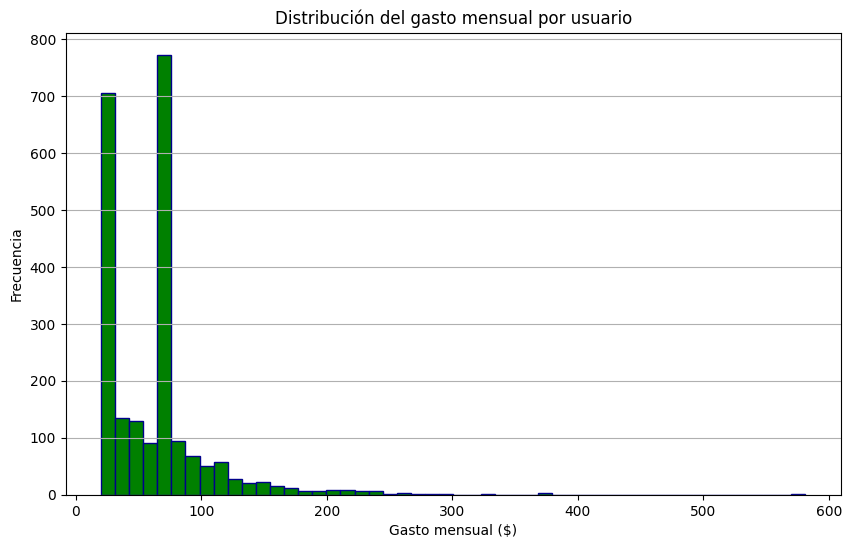

In [44]:
plt.figure(figsize=(10,6))
plt.hist(monthly['gasto_total_mes'], color = 'green', bins=50, linewidth = 1, edgecolor='darkblue')
plt.title('Distribución del gasto mensual por usuario')
plt.xlabel('Gasto mensual ($)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha = 1)

plt.show()


La mayoría de usuarios ajusta el consumo a su plan (surf `$20`) (ultimate `$70`)

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

In [45]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.



In [46]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.



[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [47]:
# Calcula la media y la varianza de la duración mensual de llamadas.



In [48]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas



[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

### Mensajes

In [49]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan



In [50]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan



[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

### Internet

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [51]:
# Prueba las hipótesis



[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [52]:
# Prueba las hipótesis



## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]